# 01. Data Exploration & Validation Checks

In this notebook, we load and validate the generated `dataset.csv` against the requirements described in Section 3 and Section 6.2 of the project workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import config

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

C:\Users\saran\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. Load Dataset

In [2]:
df = pd.read_csv('dataset.csv')
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
print("Columns:", df.columns.tolist())
df.head()

Dataset loaded successfully with 1000000 rows and 25 columns.
Columns: ['Time', 'PatientID', 'SliceID', 'HeartRate', 'BP', 'SpO2', 'Emergency', 'Priority', 'Traffic', 'Traffic_t-3', 'Traffic_t-2', 'Traffic_t-1', 'DataSize', 'SINR', 'Queue', 'Lambda', 'Mu', 'Bandwidth', 'Latency', 'Throughput', 'Reliability', 'Power', 'REU', 'Utility', 'LatencyReq']


,Time,PatientID,SliceID,HeartRate,BP,SpO2,Emergency,Priority,Traffic,Traffic_t-3,...,Lambda,Mu,Bandwidth,Latency,Throughput,Reliability,Power,REU,Utility,LatencyReq
0,0,1,5,73.47,91.05,98.13,0,0.035971,15.728,14.591,...,1.797,4.009,0.059688,135.347618,0.210088,0.702243,113.760951,0.001847,-38.171735,100.0
1,1,1,3,91.49,100.80,98.45,0,0.075208,18.906,14.591,...,1.501,5.224,0.289498,55.444500,1.172613,0.428206,75.835034,0.015463,-18.190611,30.0
2,2,1,5,84.39,128.54,96.67,0,0.049144,25.608,14.591,...,1.530,10.908,0.092936,83.952384,0.383681,1.000000,153.421247,0.002501,-31.717247,100.0
3,3,1,4,79.75,130.82,96.60,0,0.066812,31.359,15.728,...,3.279,12.210,0.896761,53.522784,4.427193,1.000000,110.694780,0.039995,-20.141877,60.0
4,4,1,2,72.02,143.19,96.58,1,0.652623,39.467,18.906,...,3.269,10.142,3.495176,5.702028,17.052006,1.000000,95.837040,0.177927,-5.290715,15.0


## 2. Autocorrelation Check on Traffic

We plot the Traffic time series, ACF, and PACF for a few sample patients to verify that the traffic process exhibits genuine temporal correlation.
Due to deprecation issues with `statsmodels` on this system, we implement manual ACF and PACF calculations using NumPy and Pandas.

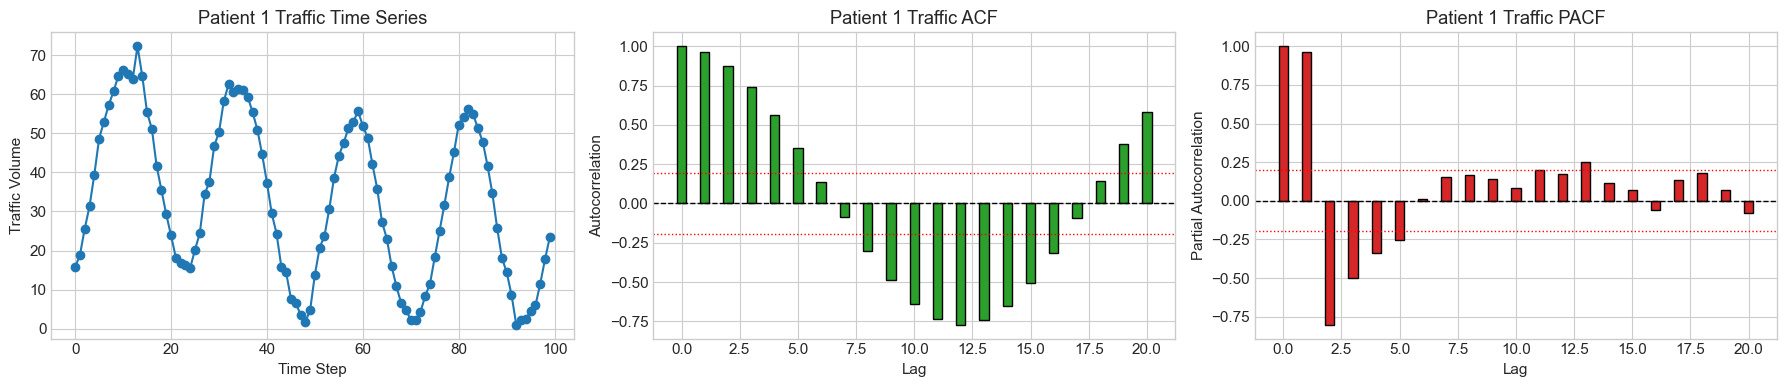

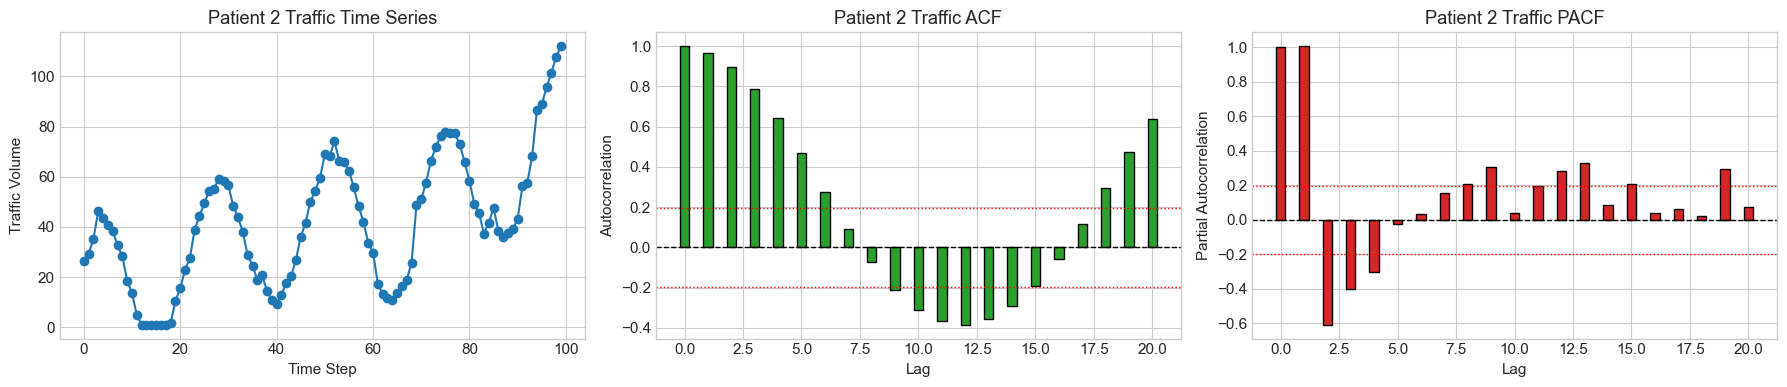

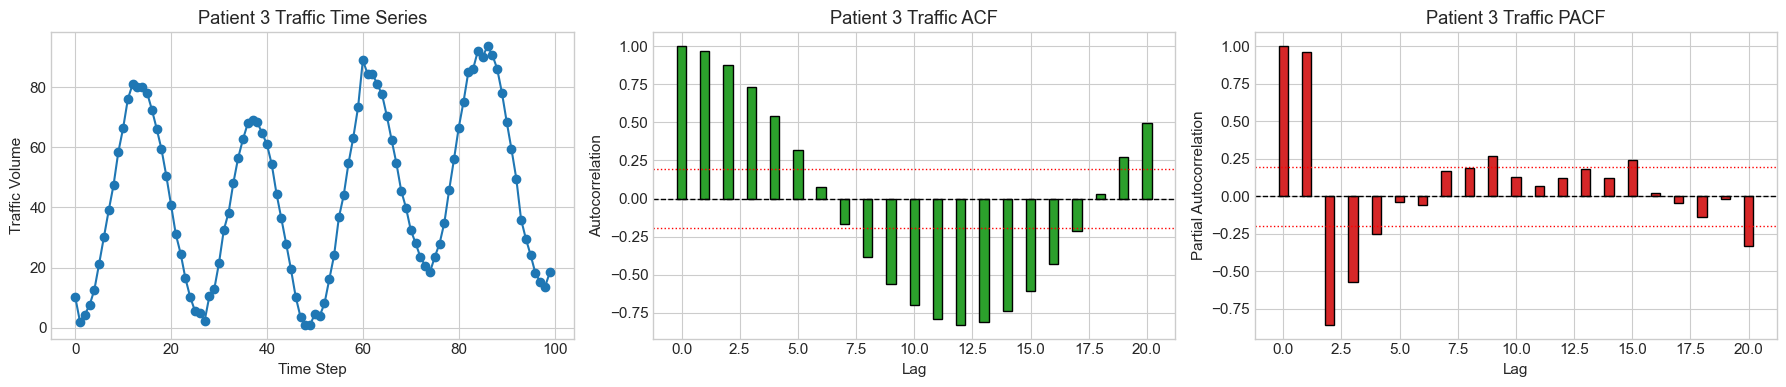

In [3]:
def compute_acf_manual(series, lags=20):
    acf_vals = [1.0]
    for i in range(1, lags + 1):
        acf_vals.append(series.autocorr(lag=i))
    return acf_vals

def compute_pacf_manual(series, lags=20):
    pacf_vals = [1.0]
    n = len(series)
    # OLS regression of x_t on lagged values
    for k in range(1, lags + 1):
        y = series[k:].values
        X = np.column_stack([series[k-i : n-i].values for i in range(1, k+1)])
        # Center
        y = y - np.mean(y)
        X = X - np.mean(X, axis=0)
        try:
            beta = np.linalg.lstsq(X, y, rcond=None)[0]
            pacf_vals.append(beta[-1])
        except Exception:
            pacf_vals.append(0.0)
    return pacf_vals

sample_patients = [1, 2, 3]
for pid in sample_patients:
    patient_df = df[df['PatientID'] == pid].sort_values('Time')
    series = patient_df['Traffic']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    # Traffic plot
    axes[0].plot(patient_df['Time'], series, marker='o', color='#1f77b4')
    axes[0].set_title(f"Patient {pid} Traffic Time Series")
    axes[0].set_xlabel("Time Step")
    axes[0].set_ylabel("Traffic Volume")
    
    # ACF plot
    lags = 20
    acf_vals = compute_acf_manual(series, lags)
    axes[1].bar(range(lags + 1), acf_vals, width=0.4, color='#2ca02c', edgecolor='black')
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    bound = 1.96 / np.sqrt(len(series))
    axes[1].axhline(bound, color='red', linestyle=':', linewidth=1)
    axes[1].axhline(-bound, color='red', linestyle=':', linewidth=1)
    axes[1].set_title(f"Patient {pid} Traffic ACF")
    axes[1].set_xlabel("Lag")
    axes[1].set_ylabel("Autocorrelation")
    
    # PACF plot
    pacf_vals = compute_pacf_manual(series, lags)
    axes[2].bar(range(lags + 1), pacf_vals, width=0.4, color='#d62728', edgecolor='black')
    axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[2].axhline(bound, color='red', linestyle=':', linewidth=1)
    axes[2].axhline(-bound, color='red', linestyle=':', linewidth=1)
    axes[2].set_title(f"Patient {pid} Traffic PACF")
    axes[2].set_xlabel("Lag")
    axes[2].set_ylabel("Partial Autocorrelation")
    
    plt.tight_layout()
    plt.show()

## 3. Shared Bandwidth Pool Check

We verify that the sum of bandwidth allocated to all patients at each time step matches `TOTAL_BW` (30000.0) exactly.

In [4]:
bw_sum = df.groupby('Time')['Bandwidth'].sum()
print("Bandwidth Sum statistics per time step:")
print(bw_sum.describe())

assert np.allclose(bw_sum, config.TOTAL_BW, atol=1e-2), "Error: Bandwidth sum is not equal to TOTAL_BW!"
print(f"\nSanity check passed! Sum of bandwidth equals TOTAL_BW ({config.TOTAL_BW}) for every time step.")

Bandwidth Sum statistics per time step:
count    1.000000e+02
mean     3.000000e+04
std      3.037156e-12
min      3.000000e+04
25%      3.000000e+04
50%      3.000000e+04
75%      3.000000e+04
max      3.000000e+04
Name: Bandwidth, dtype: float64

Sanity check passed! Sum of bandwidth equals TOTAL_BW (30000.0) for every time step.


## 4. ICU / Emergency Forced Value Check

We check that for ICU patients (`SliceID == 2`), the `Emergency` flag is always forced to 1, regardless of their vital signs.

In [5]:
icu_df = df[df['SliceID'] == 2]
emergency_ratio = icu_df['Emergency'].mean()
print(f"Total ICU rows: {len(icu_df)}")
print(f"Ratio of Emergency==1 in ICU: {emergency_ratio * 100:.2f}%")

assert (icu_df['Emergency'] == 1).all(), "Error: Some ICU rows have Emergency == 0!"
print("Sanity check passed! All SliceID==2 (ICU) rows have Emergency == 1.")

Total ICU rows: 199822
Ratio of Emergency==1 in ICU: 100.00%
Sanity check passed! All SliceID==2 (ICU) rows have Emergency == 1.


## 5. Emergency-vs-Latency Comparison per Slice

We verify that within each slice, patients with `Emergency == 1` have lower average latency and higher average reliability than those with `Emergency == 0`. This validates the Priority-DataSize weighting logic in the baseline allocation.

In [6]:
for slice_id in sorted(df['SliceID'].unique()):
    slice_df = df[df['SliceID'] == slice_id]
    
    # If a slice has no variation in Emergency (e.g. ICU is all Emergency=1), we skip comparison
    if slice_df['Emergency'].nunique() < 2:
        print(f"Slice {slice_id} has only Emergency={slice_df['Emergency'].iloc[0]} rows. Skipping comparison.")
        continue
        
    stats = slice_df.groupby('Emergency')[['Latency', 'Reliability', 'Bandwidth', 'DataSize']].mean()
    print(f"\n--- Slice {slice_id} ({config.LATENCY_REQ_MAP[slice_id]} ms Req) stats: ---")
    print(stats)
    
    latency_0 = stats.loc[0, 'Latency']
    latency_1 = stats.loc[1, 'Latency']
    rel_0 = stats.loc[0, 'Reliability']
    rel_1 = stats.loc[1, 'Reliability']
    
    assert latency_1 < latency_0, f"Error: Emergency patients in slice {slice_id} do not have lower latency!"
    assert rel_1 >= rel_0, f"Error: Emergency patients in slice {slice_id} do not have higher reliability!"

print("\nSanity check passed! Within each slice, Emergency==1 patients receive lower latency and higher/equal reliability.")


--- Slice 1 (5.0 ms Req) stats: ---
             Latency  Reliability  Bandwidth    DataSize
Emergency                                               
0          13.973111     0.191223   2.957691  159.778599
1           5.878153     0.845741  31.273490  702.029687
Slice 2 has only Emergency=1 rows. Skipping comparison.

--- Slice 3 (30.0 ms Req) stats: ---
             Latency  Reliability  Bandwidth    DataSize
Emergency                                               
0          49.328148     0.613221   0.939345  159.888466
1           8.137971     1.000000  22.390528  701.993725

--- Slice 4 (60.0 ms Req) stats: ---
             Latency  Reliability  Bandwidth    DataSize
Emergency                                               
0          70.945274     0.800951   0.736009  159.788974
1           8.503900     1.000000  21.545465  703.650767



--- Slice 5 (100.0 ms Req) stats: ---
             Latency  Reliability  Bandwidth    DataSize
Emergency                                               
0          89.701457      0.87585   0.655580  159.891476
1           8.606868      1.00000  21.055247  697.806762

Sanity check passed! Within each slice, Emergency==1 patients receive lower latency and higher/equal reliability.


## 6. Histograms of Key Columns

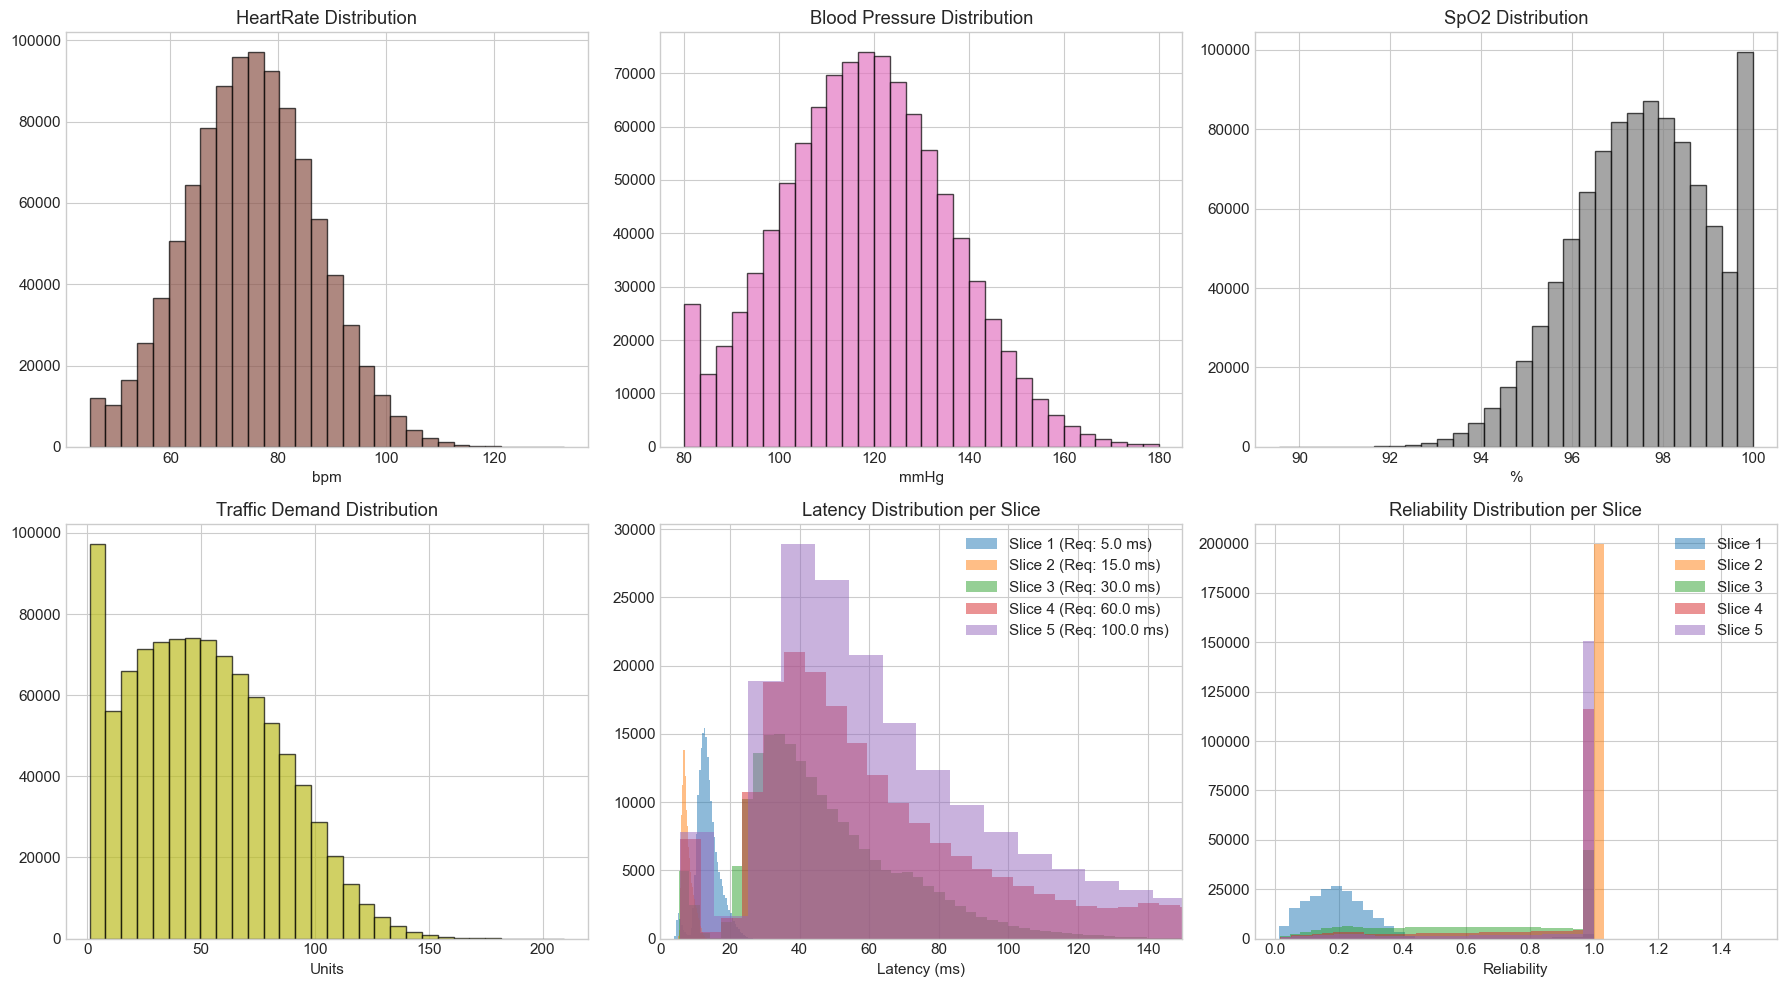

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Vitals
axes[0, 0].hist(df['HeartRate'], bins=30, color='#8c564b', edgecolor='black', alpha=0.7)
axes[0, 0].set_title("HeartRate Distribution")
axes[0, 0].set_xlabel("bpm")

axes[0, 1].hist(df['BP'], bins=30, color='#e377c2', edgecolor='black', alpha=0.7)
axes[0, 1].set_title("Blood Pressure Distribution")
axes[0, 1].set_xlabel("mmHg")

axes[0, 2].hist(df['SpO2'], bins=30, color='#7f7f7f', edgecolor='black', alpha=0.7)
axes[0, 2].set_title("SpO2 Distribution")
axes[0, 2].set_xlabel("%")

# Traffic and Latency
axes[1, 0].hist(df['Traffic'], bins=30, color='#bcbd22', edgecolor='black', alpha=0.7)
axes[1, 0].set_title("Traffic Demand Distribution")
axes[1, 0].set_xlabel("Units")

# Latency per slice
for slice_id in sorted(df['SliceID'].unique()):
    slice_df = df[df['SliceID'] == slice_id]
    axes[1, 1].hist(slice_df['Latency'], bins=50, alpha=0.5, label=f"Slice {slice_id} (Req: {config.LATENCY_REQ_MAP[slice_id]} ms)")
axes[1, 1].set_title("Latency Distribution per Slice")
axes[1, 1].set_xlabel("Latency (ms)")
axes[1, 1].legend()
axes[1, 1].set_xlim(0, 150)

# Reliability per slice
for slice_id in sorted(df['SliceID'].unique()):
    slice_df = df[df['SliceID'] == slice_id]
    axes[1, 2].hist(slice_df['Reliability'], bins=30, alpha=0.5, label=f"Slice {slice_id}")
axes[1, 2].set_title("Reliability Distribution per Slice")
axes[1, 2].set_xlabel("Reliability")
axes[1, 2].legend()

plt.tight_layout()
plt.show()